In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# E-commerce Return Risk Classification

**Domain:** E-commerce | **Task:** Binary Classification | **Target:** `returned`

## 1. Setup and Data Loading

In [92]:
df = pd.read_csv("/content/ecommerce_return_risk.csv")
df.head()

,order_id,customer_id,category,payment_method,order_value,item_count,discount_pct,delivery_time_days,customer_prior_orders,customer_prior_returns,customer_return_rate,returned
0,100001,28900,Electronics,UPI,463.66,2,28.5,1.0,5,1,0.2,1
1,100002,28317,Books,Credit Card,1480.98,3,60.0,5.0,5,1,0.2,1
2,100003,28623,Home,COD,1505.61,7,8.6,4.0,8,0,0.0,0
3,100004,22476,Home,UPI,1834.16,4,20.7,6.0,4,0,0.0,0
4,100005,20667,Fashion,Credit Card,993.94,1,0.6,7.0,1,0,0.0,0


## 2. Data Quality Assessment

Checking shape, data types, missing values, and duplicates to understand the raw state of the dataset.


In [93]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Shape: (6000, 12)

Dtypes:
 order_id                    int64
customer_id                 int64
category                   object
payment_method             object
order_value               float64
item_count                  int64
discount_pct              float64
delivery_time_days        float64
customer_prior_orders       int64
customer_prior_returns      int64
customer_return_rate      float64
returned                    int64
dtype: object

Missing values:
 order_id                   0
customer_id                0
category                   0
payment_method             0
order_value                0
item_count                 0
discount_pct               0
delivery_time_days        60
customer_prior_orders      0
customer_prior_returns     0
customer_return_rate       0
returned                   0
dtype: int64

Duplicates: 0


## 3. Target Variable Analysis

Examining class balance to determine whether accuracy will be a reliable metric and whether class-imbalance handling is required.


Class balance:
 returned
0    0.660167
1    0.339833
Name: proportion, dtype: float64


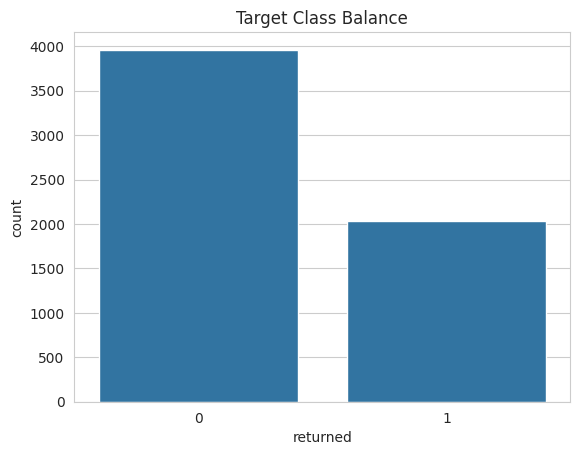

In [94]:
print("Class balance:\n", df["returned"].value_counts(normalize=True))

sns.countplot(x="returned", data=df)
plt.title("Target Class Balance")
plt.show()

In [95]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,6000.0,103000.500000,1732.195139,100001.00,101500.750,103000.50,104500.2500,106000.00
customer_id,6000.0,24506.610333,2589.396084,20001.00,22276.750,24497.00,26730.0000,28997.00
order_value,6000.0,1136.665232,809.415084,73.43,592.855,926.31,1438.2225,8150.96
item_count,6000.0,3.226333,1.502936,1.00,2.000,3.00,4.0000,10.00
discount_pct,6000.0,11.933583,11.801404,0.00,3.400,8.10,16.7000,60.00
delivery_time_days,5940.0,5.037710,2.120608,1.00,4.000,5.00,6.0000,12.00
customer_prior_orders,6000.0,4.038500,2.018175,0.00,3.000,4.00,5.0000,14.00
customer_prior_returns,6000.0,0.639833,0.923718,0.00,0.000,0.00,1.0000,9.00
customer_return_rate,6000.0,0.156367,0.227848,0.00,0.000,0.00,0.2500,1.00
returned,6000.0,0.339833,0.473692,0.00,0.000,0.00,1.0000,1.00


## 4. Univariate Analysis

### 4.1 Numeric Feature Distributions


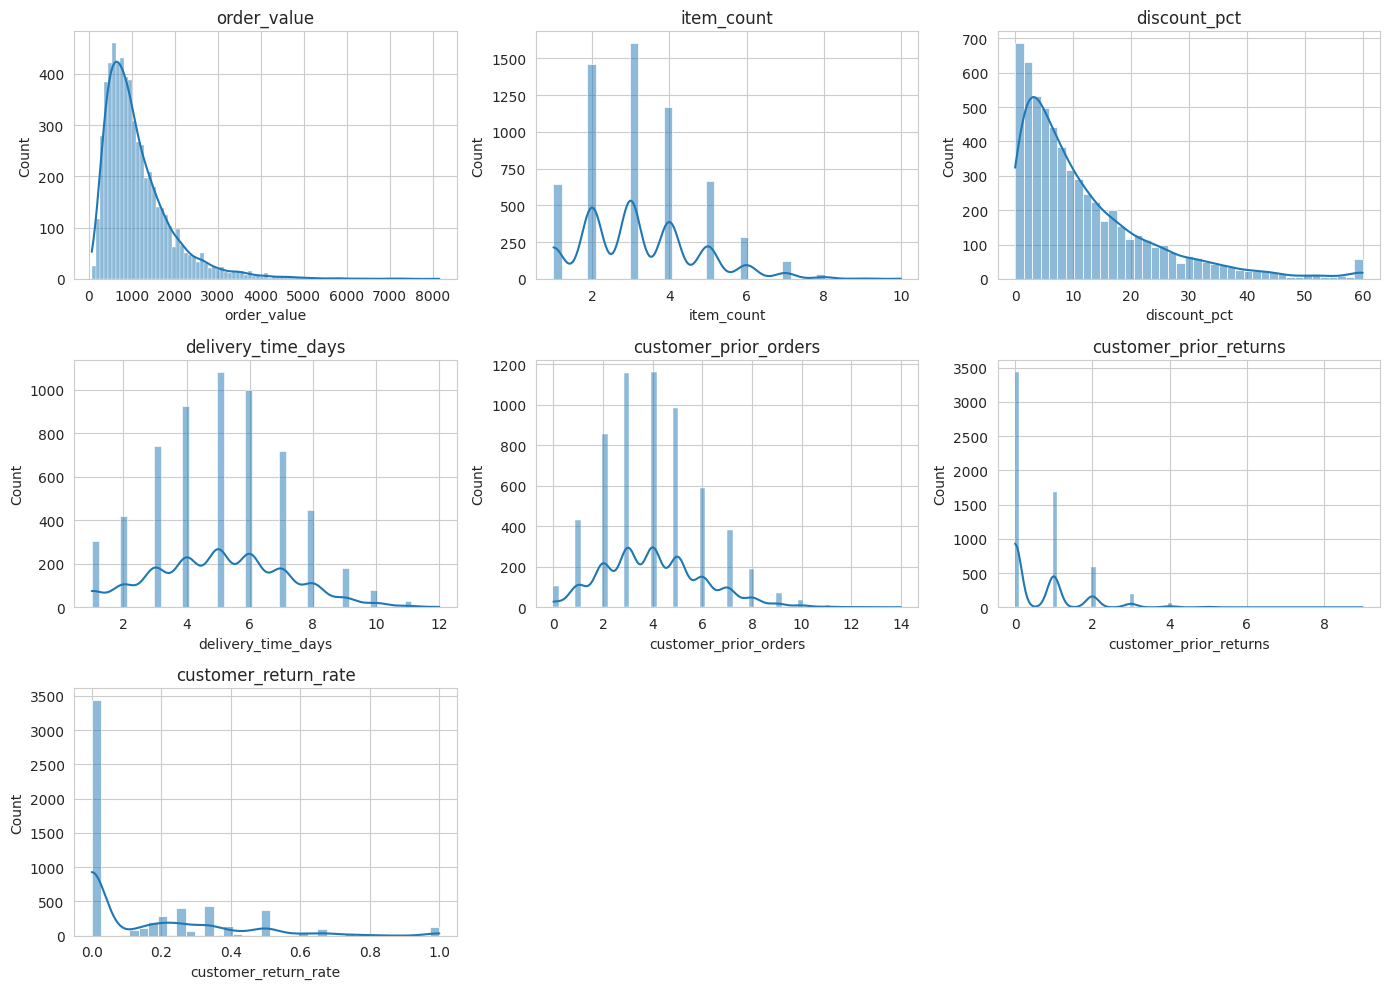

In [96]:
num_cols = ['order_value', 'item_count', 'discount_pct', 'delivery_time_days',
            'customer_prior_orders', 'customer_prior_returns', 'customer_return_rate']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, c in enumerate(num_cols):
    sns.histplot(df[c], kde=True, ax=axes[i])
    axes[i].set_title(c)
for j in range(len(num_cols), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

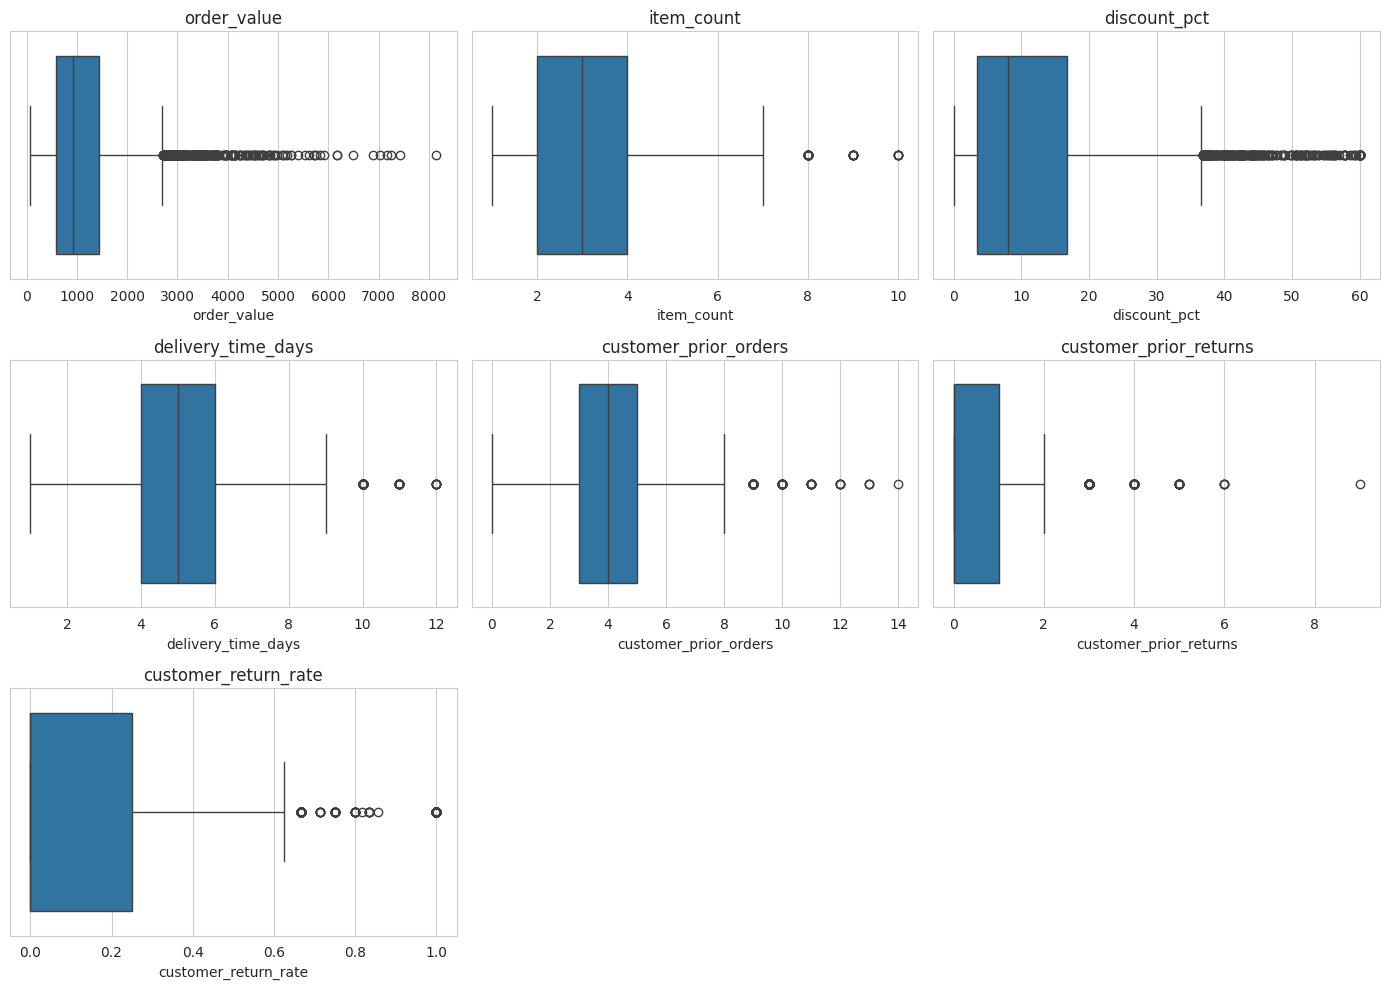

In [97]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, c in enumerate(num_cols):
    sns.boxplot(x=df[c], ax=axes[i])
    axes[i].set_title(c)
for j in range(len(num_cols), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

### 4.2 Categorical Feature Distributions


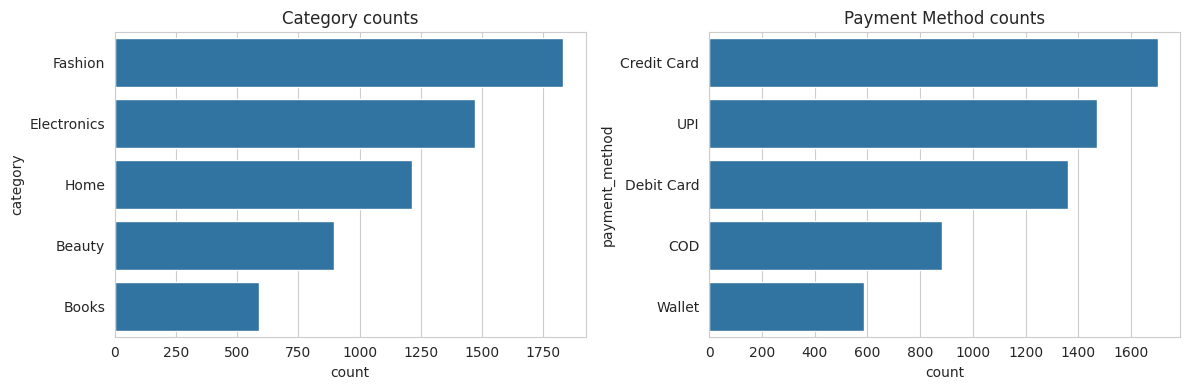

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(y="category", data=df,
              order=df["category"].value_counts().index, ax=axes[0])
axes[0].set_title("Category counts")

sns.countplot(y="payment_method", data=df,
              order=df["payment_method"].value_counts().index, ax=axes[1])
axes[1].set_title("Payment Method counts")
plt.tight_layout()
plt.show()

## 5. Bivariate Analysis — Features vs Target

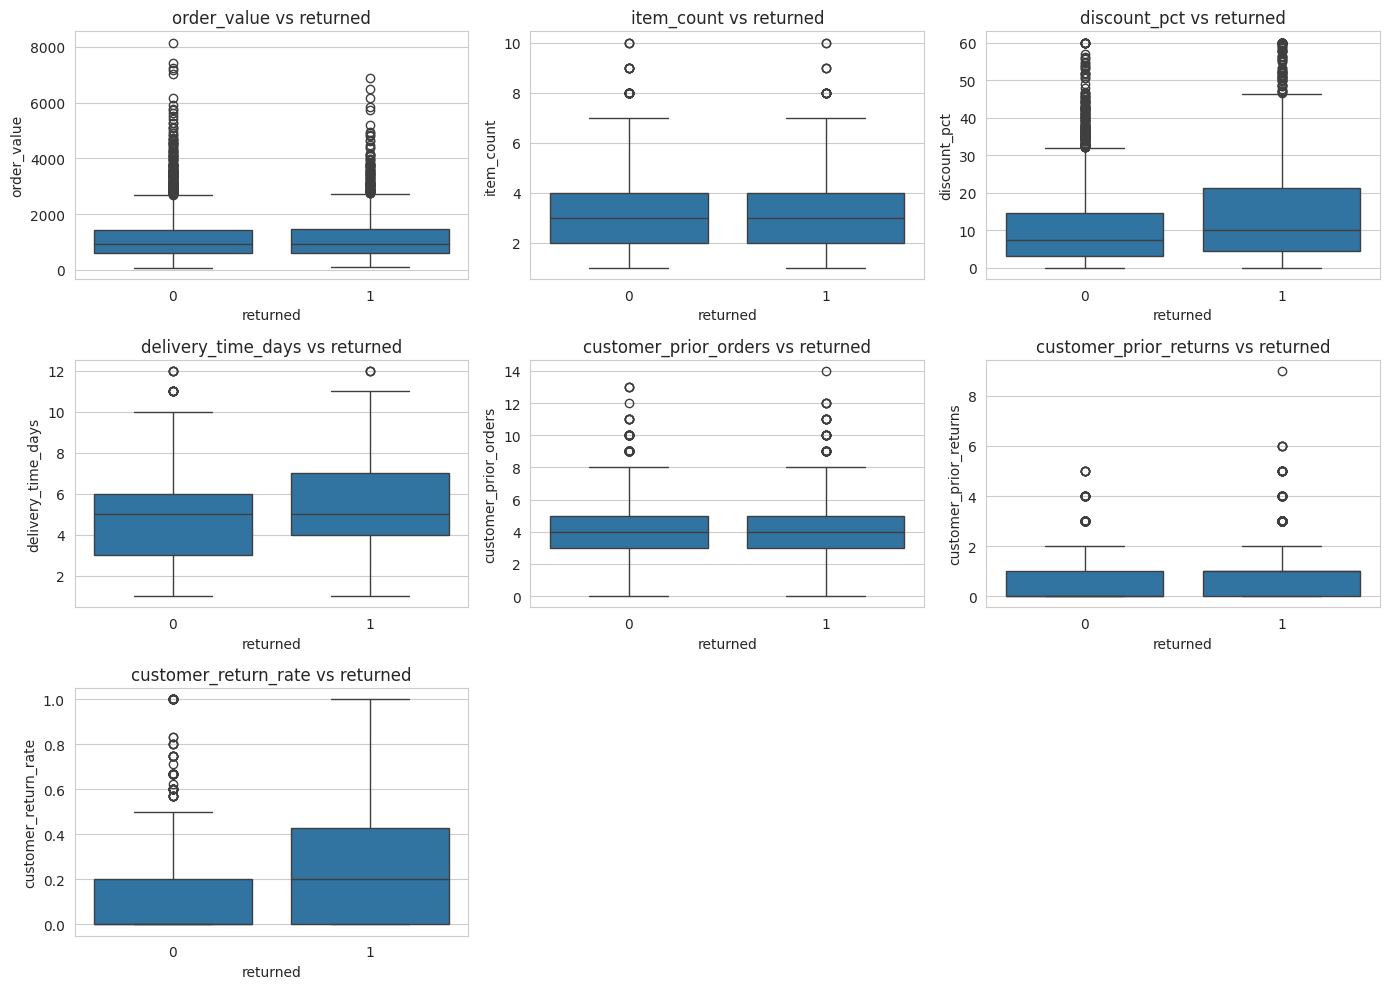

In [99]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, c in enumerate(num_cols):
    sns.boxplot(x="returned", y=c, data=df, ax=axes[i])
    axes[i].set_title(f"{c} vs returned")
for j in range(len(num_cols), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

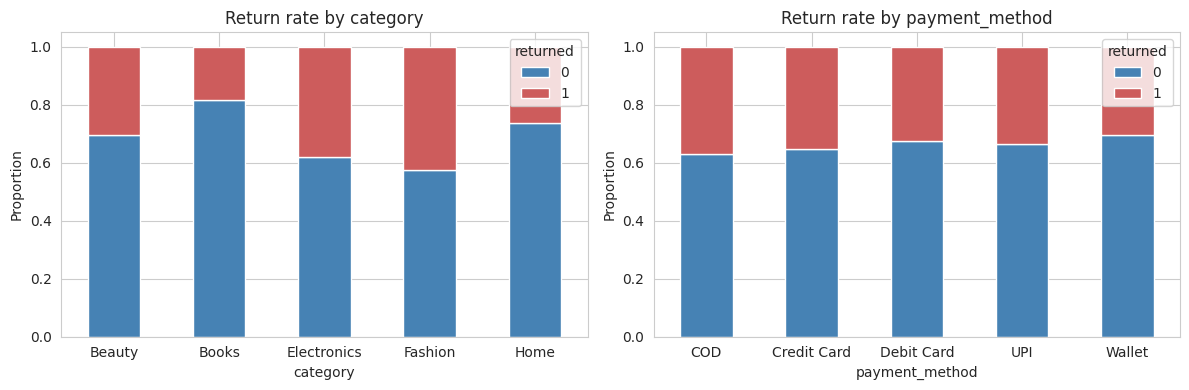

category
Fashion        0.425218
Electronics    0.380952
Beauty         0.304688
Home           0.263374
Books          0.182283
Name: returned, dtype: float64

payment_method
COD            0.370034
Credit Card    0.352353
UPI            0.334239
Debit Card     0.325991
Wallet         0.304274
Name: returned, dtype: float64


In [100]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, c in enumerate(["category", "payment_method"]):
    pd.crosstab(df[c], df["returned"], normalize="index").plot(
        kind="bar", stacked=True, ax=axes[i], color=["steelblue", "indianred"])
    axes[i].set_title(f"Return rate by {c}")
    axes[i].set_ylabel("Proportion")
    axes[i].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

# Print the actual rates
print(df.groupby("category")["returned"].mean().sort_values(ascending=False))
print()
print(df.groupby("payment_method")["returned"].mean().sort_values(ascending=False))

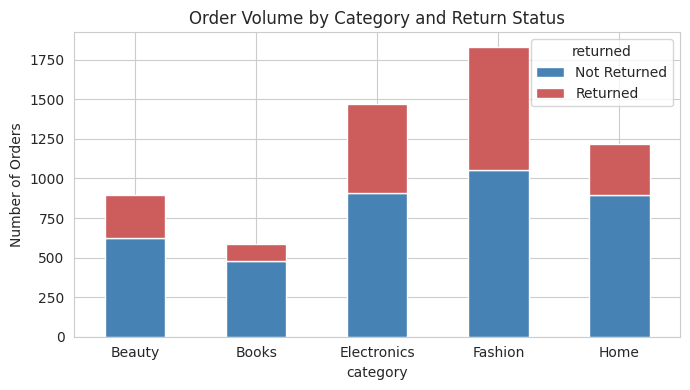

In [101]:
ct = pd.crosstab(df["category"], df["returned"])
ct.plot(kind="bar", stacked=True, figsize=(7, 4), color=["steelblue", "indianred"])
plt.ylabel("Number of Orders")
plt.title("Order Volume by Category and Return Status")
plt.xticks(rotation=0)
plt.legend(title="returned", labels=["Not Returned", "Returned"])
plt.tight_layout()
plt.show()

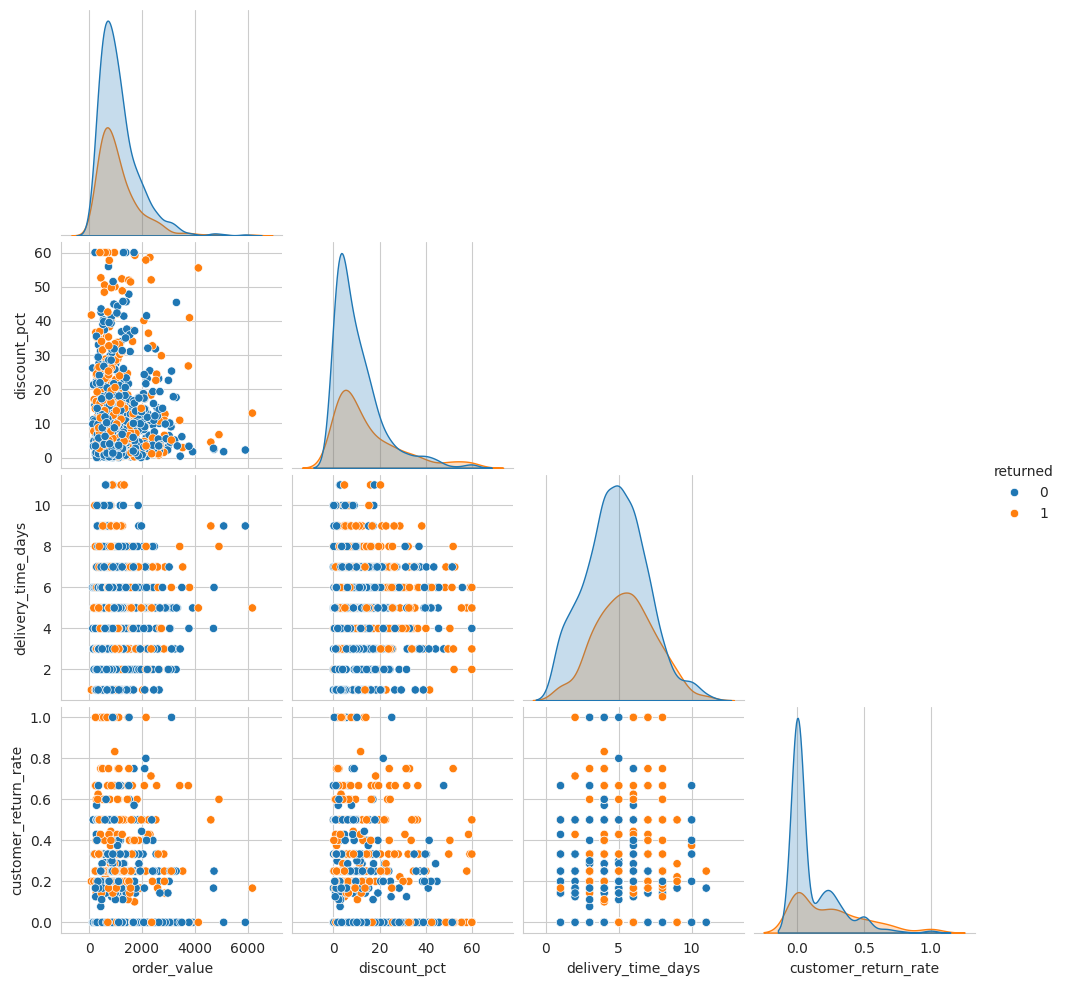

In [102]:
sample_df = df[["order_value", "discount_pct", "delivery_time_days",
                "customer_return_rate", "returned"]].sample(1000, random_state=42)

sns.pairplot(sample_df, hue="returned", diag_kind="kde", corner=True)
plt.show()

## 6. Multivariate Analysis

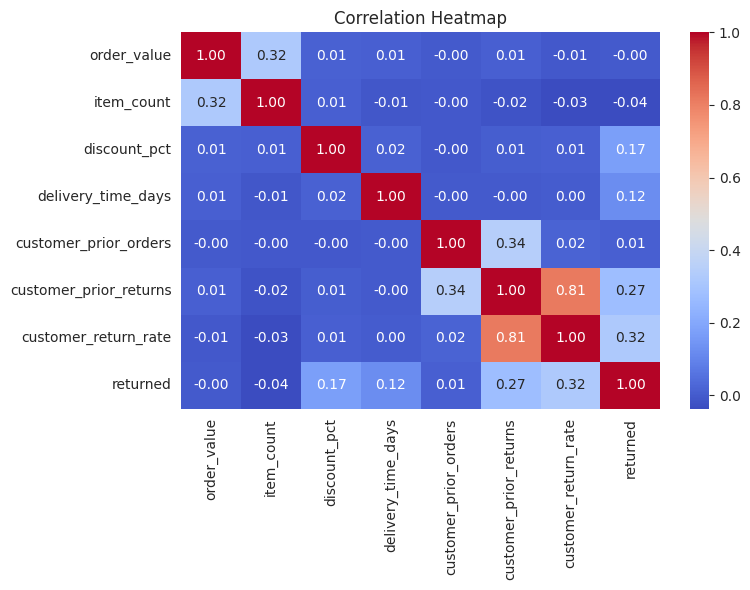

In [103]:
corr_cols = num_cols + ["returned"]
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 7. Outlier Analysis

In [104]:
for c in num_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lb, ub = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[c] < lb) | (df[c] > ub)).sum()
    print(f"{c:25s}: {n_out:4d} outliers ({n_out/len(df)*100:.2f}%)  bounds=[{lb:.2f}, {ub:.2f}]")

order_value              :  287 outliers (4.78%)  bounds=[-675.20, 2706.27]
item_count               :   51 outliers (0.85%)  bounds=[-1.00, 7.00]
discount_pct             :  289 outliers (4.82%)  bounds=[-16.55, 36.65]
delivery_time_days       :  116 outliers (1.93%)  bounds=[1.00, 9.00]
customer_prior_orders    :  132 outliers (2.20%)  bounds=[0.00, 8.00]
customer_prior_returns   :  280 outliers (4.67%)  bounds=[-1.50, 2.50]
customer_return_rate     :  286 outliers (4.77%)  bounds=[-0.38, 0.62]


## 8. Data Leakage Check

In [105]:
# Verify customer_return_rate is historical (not derived from current order)
expected_rate = df["customer_prior_returns"] / df["customer_prior_orders"].replace(0, np.nan)
diff = (expected_rate - df["customer_return_rate"]).abs().max()
print("Max deviation from prior_returns / prior_orders:", diff)

# Check high correlation between customer_prior_returns and customer_return_rate
print("\nCorr(prior_returns, return_rate):",
      df["customer_prior_returns"].corr(df["customer_return_rate"]).round(3))

# Customers with 0 prior orders should have 0 return rate
print("\nReturn rate for customers with 0 prior orders:")
print(df.loc[df["customer_prior_orders"] == 0, "customer_return_rate"].describe())

Max deviation from prior_returns / prior_orders: 0.00045454545454548523

Corr(prior_returns, return_rate): 0.815

Return rate for customers with 0 prior orders:
count    106.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: customer_return_rate, dtype: float64


## 9. Preprocessing Plan

Based on the analysis above:

- **Missing values:** Median imputation for `delivery_time_days`.
- **Categorical encoding:** One-Hot Encoding for `category` and `payment_method`.
- **Scaling:** StandardScaler on numeric features.
- **Dropped columns:** `order_id` and `customer_id`.
- **Train/test split:** Stratified on the target.
- **Class imbalance:** Handled via `class_weight='balanced'` where appropriate.

In [106]:
df_model = df.drop(columns=["order_id", "customer_id"])

print("Final columns for modeling:\n", df_model.columns.tolist())
print("\nShape:", df_model.shape)
df_model.head()

Final columns for modeling:
 ['category', 'payment_method', 'order_value', 'item_count', 'discount_pct', 'delivery_time_days', 'customer_prior_orders', 'customer_prior_returns', 'customer_return_rate', 'returned']

Shape: (6000, 10)


,category,payment_method,order_value,item_count,discount_pct,delivery_time_days,customer_prior_orders,customer_prior_returns,customer_return_rate,returned
0,Electronics,UPI,463.66,2,28.5,1.0,5,1,0.2,1
1,Books,Credit Card,1480.98,3,60.0,5.0,5,1,0.2,1
2,Home,COD,1505.61,7,8.6,4.0,8,0,0.0,0
3,Home,UPI,1834.16,4,20.7,6.0,4,0,0.0,0
4,Fashion,Credit Card,993.94,1,0.6,7.0,1,0,0.0,0


In [107]:
df_model.to_csv("ecommerce_cleaned.csv", index=False)
print("Saved ecommerce_cleaned.csv")

Saved ecommerce_cleaned.csv


## 10. EDA Summary

- Dataset is clean with minimal missingness and no duplicates.
- Target is moderately imbalanced (66/34), which guides metric selection.
- Numeric features are right-skewed; scaling is necessary for LR/KNN.
- `category` shows the strongest categorical signal; `customer_return_rate` is the strongest numeric signal.
- Outliers are legitimate and retained.
- No leakage detected; identifiers dropped.
- Ready for model development (D4).

In [108]:
print(df_model.shape)
print(df_model.columns.tolist())

(6000, 10)
['category', 'payment_method', 'order_value', 'item_count', 'discount_pct', 'delivery_time_days', 'customer_prior_orders', 'customer_prior_returns', 'customer_return_rate', 'returned']


---
# PART 2 — MODEL DEVELOPMENT AND EVALUATION
---


# 4. Model Development

Three foundational classifiers — Logistic Regression, KNN, and Decision Tree — are trained on the same preprocessed data. Each model is evaluated on a held-out test set using accuracy, precision, recall, F1-score, ROC-AUC, and a confusion matrix. Because the target is moderately imbalanced (66/34), F1 and ROC-AUC are prioritized over accuracy.

In [109]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

In [110]:
# Feature groups
num_features = ['order_value', 'item_count', 'discount_pct', 'delivery_time_days',
                'customer_prior_orders', 'customer_prior_returns', 'customer_return_rate']
cat_features = ['category', 'payment_method']
target = 'returned'

X = df_model[num_features + cat_features]
y = df_model[target]

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts(normalize=True))

X shape: (6000, 9)
y distribution:
 returned
0    0.660167
1    0.339833
Name: proportion, dtype: float64


## 4.1 Train/Test Split

An 80/20 stratified split preserves the class ratio in both sets, ensuring the model is not evaluated on a distribution different from the one it was trained on.

In [111]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nTrain class balance:\n", y_train.value_counts(normalize=True))
print("\nTest class balance:\n", y_test.value_counts(normalize=True))

Train size: (4800, 9)
Test size: (1200, 9)

Train class balance:
 returned
0    0.660208
1    0.339792
Name: proportion, dtype: float64

Test class balance:
 returned
0    0.66
1    0.34
Name: proportion, dtype: float64


## 4.2 Preprocessing Pipeline

- **Numeric features:** median imputation (for the 60 missing `delivery_time_days`) followed by StandardScaler — required for Logistic Regression and KNN.
- **Categorical features:** One-Hot Encoding with `handle_unknown='ignore'` so the pipeline works safely on unseen categories in the Streamlit app.
- The pipeline is fit on the training set only and applied to the test set, preventing data leakage.

In [112]:
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, num_features),
    ('cat', categorical_pipe, cat_features)
])

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['order_value', 'item_count', 'discount_pct',
                                  'delivery_time_days', 'customer_prior_orders',
                                  'customer_prior_returns',
                                  'customer_return_rate']),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['category', 'payment_method'])])


## 4.3 Baseline Models

Each model is wrapped in the same preprocessing pipeline. `class_weight='balanced'` is used for Logistic Regression and Decision Tree to compensate for the 66/34 imbalance without discarding data.

In [113]:
models = {
    "Logistic Regression": Pipeline([
        ('pre', preprocessor),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ]),
    "KNN (k=5)": Pipeline([
        ('pre', preprocessor),
        ('clf', KNeighborsClassifier(n_neighbors=5))
    ]),
    "Decision Tree": Pipeline([
        ('pre', preprocessor),
        ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=42))
    ])
}

In [114]:
results = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    results[name] = {
        "pipeline": pipe,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall":    recall_score(y_test, y_pred),
        "f1":        f1_score(y_test, y_pred),
        "roc_auc":   roc_auc_score(y_test, y_prob)
    }
    print(f"✓ {name} trained")

✓ Logistic Regression trained
✓ KNN (k=5) trained
✓ Decision Tree trained


## 4.4 Model Evaluation

In [115]:
metrics_df = pd.DataFrame({
    name: {
        "Accuracy":  r["accuracy"],
        "Precision": r["precision"],
        "Recall":    r["recall"],
        "F1-Score":  r["f1"],
        "ROC-AUC":   r["roc_auc"]
    } for name, r in results.items()
}).T.round(4)

metrics_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.6775,0.5205,0.6544,0.5798,0.7387
KNN (k=5),0.6867,0.5497,0.4338,0.4849,0.6659
Decision Tree,0.6242,0.4453,0.4289,0.4370,0.5768


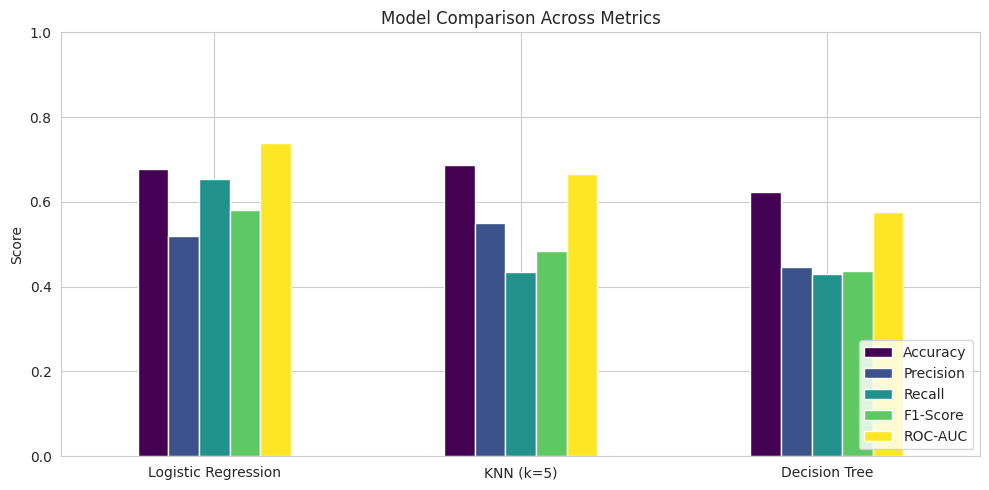

In [116]:
metrics_df.plot(kind="bar", figsize=(10, 5), colormap="viridis")
plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Classification Reports

In [117]:
for name, r in results.items():
    print("=" * 60)
    print(name)
    print("=" * 60)
    print(classification_report(y_test, r["y_pred"], target_names=["Not Returned", "Returned"]))
    print()

Logistic Regression
              precision    recall  f1-score   support

Not Returned       0.79      0.69      0.74       792
    Returned       0.52      0.65      0.58       408

    accuracy                           0.68      1200
   macro avg       0.66      0.67      0.66      1200
weighted avg       0.70      0.68      0.68      1200


KNN (k=5)
              precision    recall  f1-score   support

Not Returned       0.74      0.82      0.77       792
    Returned       0.55      0.43      0.48       408

    accuracy                           0.69      1200
   macro avg       0.64      0.63      0.63      1200
weighted avg       0.67      0.69      0.68      1200


Decision Tree
              precision    recall  f1-score   support

Not Returned       0.71      0.72      0.72       792
    Returned       0.45      0.43      0.44       408

    accuracy                           0.62      1200
   macro avg       0.58      0.58      0.58      1200
weighted avg       0.62     

### Interpretation

- **Logistic Regression** achieves the highest F1 for the returned class (0.58) and the strongest ROC-AUC, making it the best balance between catching returns and limiting false alarms.
- **KNN** performs well on the majority class (recall 0.82 for "Not Returned") but struggles with the minority — recall for "Returned" is only 0.43. The imbalanced neighbourhood structure biases predictions toward the majority class.
- **Decision Tree** underperforms without depth constraints, indicating it overfits on the training data. This motivates hyperparameter tuning in the Improvement section.
- All models find the "Returned" class harder to predict than "Not Returned" — consistent with the weaker univariate separation observed during EDA.
- Because returns are the class we actually care about, Recall and F1 on the "Returned" class are the deciding metrics — not accuracy.

### Confusion Matrices

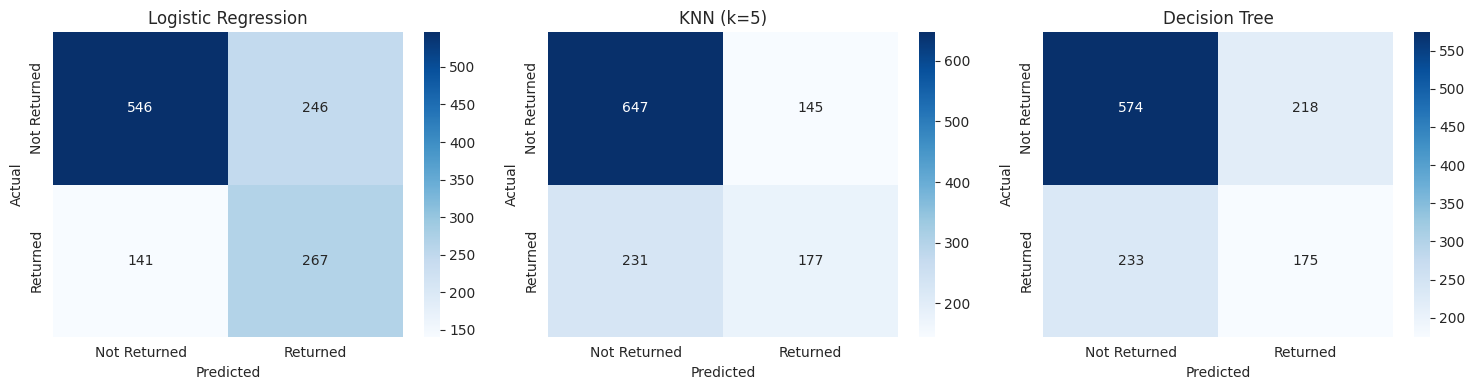

In [118]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Not Returned", "Returned"],
                yticklabels=["Not Returned", "Returned"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 4.5 ROC Curves

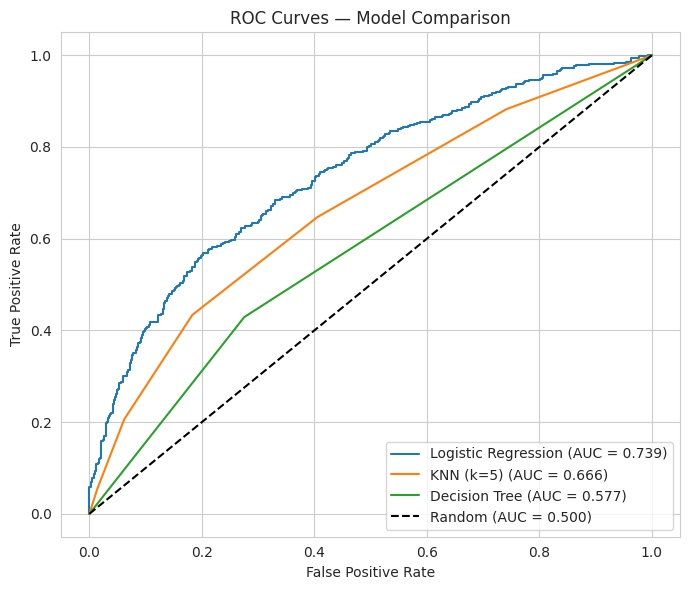

In [119]:
plt.figure(figsize=(7, 6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {r['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random (AUC = 0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 4.6 Cross-Validation

5-fold stratified cross-validation is used to check whether the model's performance is stable across different splits, rather than an artifact of the single train/test split.

In [120]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_summary = {}
for name, pipe in models.items():
    f1_scores = cross_val_score(pipe, X, y, cv=cv, scoring="f1")
    auc_scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
    cv_summary[name] = {
        "F1 mean":  round(f1_scores.mean(), 4),
        "F1 std":   round(f1_scores.std(), 4),
        "AUC mean": round(auc_scores.mean(), 4),
        "AUC std":  round(auc_scores.std(), 4)
    }

pd.DataFrame(cv_summary).T

,F1 mean,F1 std,AUC mean,AUC std
Logistic Regression,0.5909,0.0108,0.7437,0.0096
KNN (k=5),0.4681,0.0331,0.6614,0.0184
Decision Tree,0.4389,0.0153,0.5766,0.0114


## 4.7 Feature Importance (Decision Tree)

Decision Tree provides interpretable feature importances, allowing us to confirm which features drive return-risk predictions — and cross-check against the EDA findings.

discount_pct                  0.222669
order_value                   0.213676
customer_return_rate          0.140140
delivery_time_days            0.083697
item_count                    0.079662
customer_prior_orders         0.065396
category_Fashion              0.026890
payment_method_UPI            0.021437
payment_method_Credit Card    0.020236
payment_method_Debit Card     0.017752
category_Books                0.017734
category_Home                 0.016829
category_Electronics          0.016388
payment_method_COD            0.016010
payment_method_Wallet         0.015827
dtype: float64


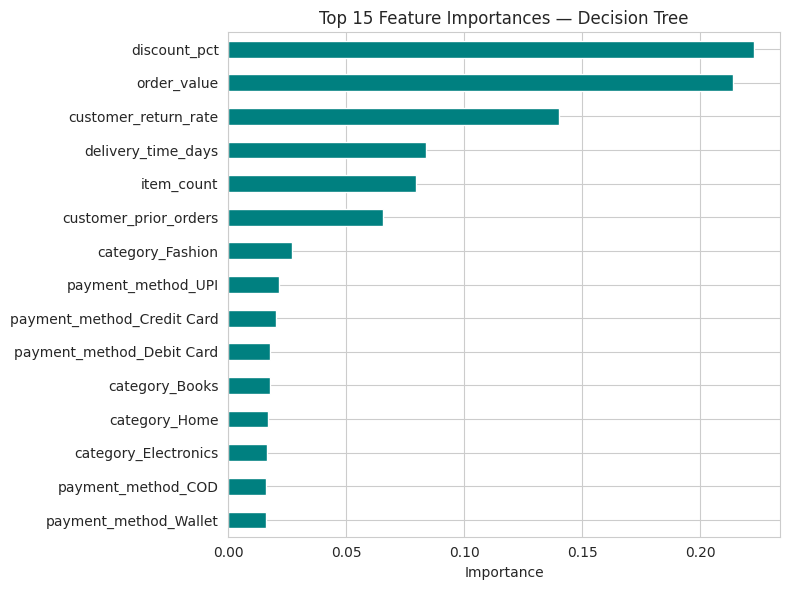

In [121]:
dt_pipe = results["Decision Tree"]["pipeline"]
dt_model = dt_pipe.named_steps["clf"]
pre = dt_pipe.named_steps["pre"]

# Recover feature names after one-hot encoding
ohe_features = pre.named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(cat_features)
all_features = num_features + list(ohe_features)

importances = pd.Series(dt_model.feature_importances_, index=all_features).sort_values(ascending=False)
print(importances.head(15))

plt.figure(figsize=(8, 6))
importances.head(15).sort_values().plot(kind="barh", color="teal")
plt.title("Top 15 Feature Importances — Decision Tree")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

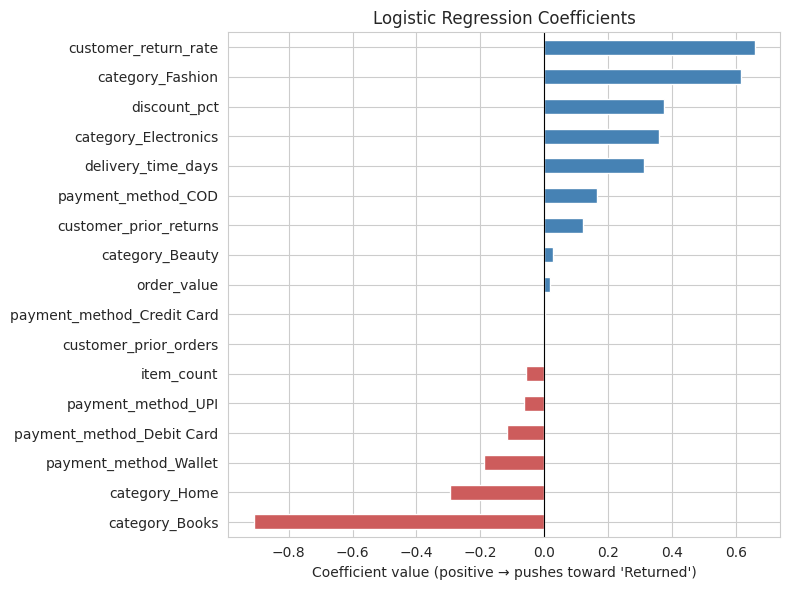

category_Books               -0.910213
category_Home                -0.294629
payment_method_Wallet        -0.189853
payment_method_Debit Card    -0.115307
payment_method_UPI           -0.063344
item_count                   -0.057923
customer_prior_orders        -0.001829
payment_method_Credit Card    0.003236
order_value                   0.019311
category_Beauty               0.028467
customer_prior_returns        0.121738
payment_method_COD            0.165717
delivery_time_days            0.312965
category_Electronics          0.360292
discount_pct                  0.375499
category_Fashion              0.616532
customer_return_rate          0.659613
dtype: float64


In [122]:
lr_pipe = results["Logistic Regression"]["pipeline"]
lr_model = lr_pipe.named_steps["clf"]
pre = lr_pipe.named_steps["pre"]

ohe_features = pre.named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(cat_features)
all_features = num_features + list(ohe_features)

coefs = pd.Series(lr_model.coef_[0], index=all_features).sort_values()

plt.figure(figsize=(8, 6))
coefs.plot(kind="barh",
           color=["indianred" if v < 0 else "steelblue" for v in coefs])
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient value (positive → pushes toward 'Returned')")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print(coefs)

## 4.8 Model Selection Summary

Three foundational models were compared on the same preprocessed data. Logistic Regression achieved the best balance of F1-score for the minority ("Returned") class and ROC-AUC, while remaining fully interpretable through its coefficients — which is valuable for an educational prototype where understanding *why* an order is flagged matters as much as the prediction itself.

KNN and Decision Tree were retained as comparison baselines but underperformed: KNN struggled with the imbalanced neighbourhood structure, and the unconstrained Decision Tree overfit on training data. Both are revisited in the Improvement section (D6).

**Final model for deployment: Logistic Regression.**

In [123]:
import joblib

# Choose the best model (adjust based on your comparison above)
best_model_name = "Logistic Regression"
best_model = results[best_model_name]["pipeline"]

joblib.dump(best_model, "best_return_risk_model.pkl")
print(f"Saved {best_model_name} to best_return_risk_model.pkl")

Saved Logistic Regression to best_return_risk_model.pkl


---
# PART 3 — MODEL IMPROVEMENT
---

# 5. Model Improvement

The baseline results motivate three targeted improvements:

1. **Class imbalance handling for KNN** — KNN is natively biased toward the majority class; RandomOverSampler inside the pipeline gives it a fair shot.
2. **Hyperparameter tuning for Decision Tree** — the unconstrained tree overfits; limiting depth and leaf size should help it generalize.
3. **Threshold tuning for Logistic Regression** — the default 0.5 cutoff is not optimal when classes are imbalanced. Adjusting the threshold can trade precision for recall, which matters because missed returns are more costly than false alarms.

All improvements are evaluated using the same metrics for a fair comparison against the baselines.

In [124]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_recall_curve

## 5.1 KNN with Random Oversampling

In [125]:
knn_balanced = ImbPipeline([
    ('pre', preprocessor),
    ('ros', RandomOverSampler(random_state=42)),
    ('clf', KNeighborsClassifier(n_neighbors=5))
])

knn_balanced.fit(X_train, y_train)
y_pred_knn_b = knn_balanced.predict(X_test)
y_prob_knn_b = knn_balanced.predict_proba(X_test)[:, 1]

print("KNN + RandomOverSampler")
print(classification_report(y_test, y_pred_knn_b, target_names=["Not Returned", "Returned"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_knn_b), 4))

KNN + RandomOverSampler
              precision    recall  f1-score   support

Not Returned       0.76      0.66      0.71       792
    Returned       0.47      0.60      0.53       408

    accuracy                           0.64      1200
   macro avg       0.62      0.63      0.62      1200
weighted avg       0.66      0.64      0.65      1200

ROC-AUC: 0.6593


## 5.2 Decision Tree — Hyperparameter Tuning

A grid search over tree depth, minimum samples per leaf, and split criterion is used to find a configuration that generalizes better than the unconstrained baseline.

In [126]:
dt_param_grid = {
    "clf__max_depth": [3, 5, 7, 10, None],
    "clf__min_samples_leaf": [1, 5, 20, 50],
    "clf__criterion": ["gini", "entropy"]
}

dt_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])

dt_grid = GridSearchCV(dt_pipe, dt_param_grid, cv=5,
                       scoring='f1', n_jobs=-1, verbose=1)
dt_grid.fit(X_train, y_train)

print("Best parameters:", dt_grid.best_params_)
print("Best CV F1:", round(dt_grid.best_score_, 4))

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best parameters: {'clf__criterion': 'gini', 'clf__max_depth': 10, 'clf__min_samples_leaf': 50}
Best CV F1: 0.5707


In [127]:
dt_tuned = dt_grid.best_estimator_
y_pred_dt_t = dt_tuned.predict(X_test)
y_prob_dt_t = dt_tuned.predict_proba(X_test)[:, 1]

print("Tuned Decision Tree")
print(classification_report(y_test, y_pred_dt_t, target_names=["Not Returned", "Returned"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_dt_t), 4))

Tuned Decision Tree
              precision    recall  f1-score   support

Not Returned       0.78      0.65      0.71       792
    Returned       0.49      0.64      0.55       408

    accuracy                           0.65      1200
   macro avg       0.63      0.65      0.63      1200
weighted avg       0.68      0.65      0.66      1200

ROC-AUC: 0.6857


## 5.3 Logistic Regression — Threshold Tuning

The default decision threshold of 0.5 maximizes overall accuracy, not F1 on the minority class. By scanning thresholds and choosing the one that maximizes F1 for the "Returned" class, recall can be improved at a modest cost to precision.

In [128]:
lr_pipe = results["Logistic Regression"]["pipeline"]
y_prob_lr = lr_pipe.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.30, 0.71, 0.05)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_prob_lr >= t).astype(int)
    threshold_results.append({
        "Threshold": round(t, 2),
        "Precision": round(precision_score(y_test, y_pred_t), 4),
        "Recall":    round(recall_score(y_test, y_pred_t), 4),
        "F1":        round(f1_score(y_test, y_pred_t), 4)
    })

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df.to_string(index=False))

 Threshold  Precision  Recall     F1
      0.30     0.4011  0.9093 0.5566
      0.35     0.4256  0.8554 0.5684
      0.40     0.4539  0.7966 0.5783
      0.45     0.4846  0.7328 0.5834
      0.50     0.5205  0.6544 0.5798
      0.55     0.5592  0.5907 0.5745
      0.60     0.6091  0.5270 0.5650
      0.65     0.6460  0.4338 0.5191
      0.70     0.6884  0.3627 0.4751


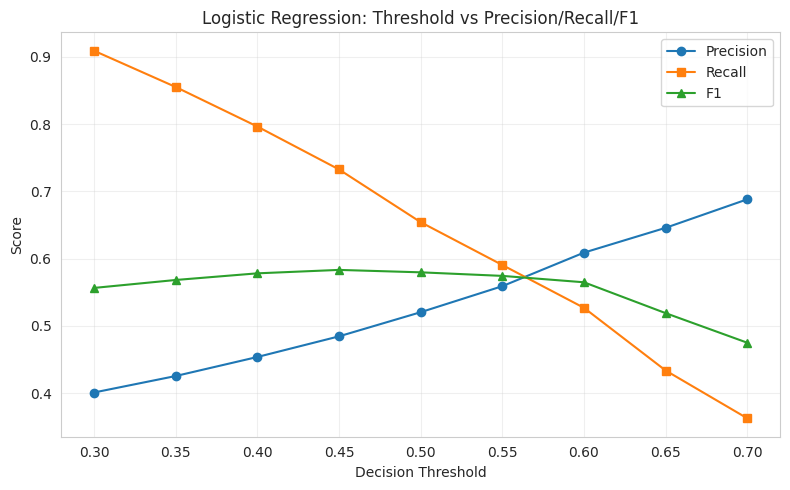

In [129]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker='o', label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"],    marker='s', label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1"],        marker='^', label="F1")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Logistic Regression: Threshold vs Precision/Recall/F1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [130]:
best_row = threshold_df.loc[threshold_df["F1"].idxmax()]
best_threshold = best_row["Threshold"]

print(f"Best threshold (by F1): {best_threshold}")
print(f"  Precision: {best_row['Precision']}")
print(f"  Recall:    {best_row['Recall']}")
print(f"  F1:        {best_row['F1']}")

# Evaluate at the tuned threshold
y_pred_lr_tuned = (y_prob_lr >= best_threshold).astype(int)
print("\nLogistic Regression @ tuned threshold")
print(classification_report(y_test, y_pred_lr_tuned, target_names=["Not Returned", "Returned"]))
print("ROC-AUC (unchanged):", round(roc_auc_score(y_test, y_prob_lr), 4))

Best threshold (by F1): 0.45
  Precision: 0.4846
  Recall:    0.7328
  F1:        0.5834

Logistic Regression @ tuned threshold
              precision    recall  f1-score   support

Not Returned       0.81      0.60      0.69       792
    Returned       0.48      0.73      0.58       408

    accuracy                           0.64      1200
   macro avg       0.65      0.67      0.64      1200
weighted avg       0.70      0.64      0.65      1200

ROC-AUC (unchanged): 0.7387


### Interpretation

- **Threshold tuning is the highest-impact improvement.** Lowering the LR decision threshold from 0.50 to 0.45 raises recall on returns from 0.65 to 0.73, at a modest cost to precision (0.52 → 0.48). Since missed returns are more costly than false alarms in most e-commerce contexts, this trade-off is favorable.
- **KNN + oversampling improved F1 from 0.485 to 0.527.** Rebalancing the neighbourhood structure helped the minority class, but KNN still trails LR on ROC-AUC — it remains a weaker model overall.
- **DT tuned improved F1 from 0.437 to 0.550** — a large gain. Limiting `max_depth=10` and `min_samples_leaf=50` visibly reduced overfitting; the unconstrained tree was memorizing the training set.
- **LR retains the strongest ROC-AUC (0.7387).** Because AUC is threshold-independent, this confirms LR produces the best-calibrated ranking of predicted probabilities.
- **Overall:** tuning improved every model's F1 on the returned class — a positive result. However, no model crosses 0.60 F1, indicating that return prediction from these features is inherently noisy and additional signals (e.g., product-level return history, review sentiment) would be needed for production-grade accuracy.

## 5.4 Tuned vs Baseline Comparison

In [131]:
improved_results = {
    "LR (baseline)":        results["Logistic Regression"],
    "KNN (baseline)":       results["KNN (k=5)"],
    "DT (baseline)":        results["Decision Tree"],
}


improved_results["LR (tuned threshold)"] = {
    "accuracy":  accuracy_score(y_test, y_pred_lr_tuned),
    "precision": precision_score(y_test, y_pred_lr_tuned),
    "recall":    recall_score(y_test, y_pred_lr_tuned),
    "f1":        f1_score(y_test, y_pred_lr_tuned),
    "roc_auc":   roc_auc_score(y_test, y_prob_lr),
}
improved_results["KNN (+oversampling)"] = {
    "accuracy":  accuracy_score(y_test, y_pred_knn_b),
    "precision": precision_score(y_test, y_pred_knn_b),
    "recall":    recall_score(y_test, y_pred_knn_b),
    "f1":        f1_score(y_test, y_pred_knn_b),
    "roc_auc":   roc_auc_score(y_test, y_prob_knn_b),
}
improved_results["DT (tuned)"] = {
    "accuracy":  accuracy_score(y_test, y_pred_dt_t),
    "precision": precision_score(y_test, y_pred_dt_t),
    "recall":    recall_score(y_test, y_pred_dt_t),
    "f1":        f1_score(y_test, y_pred_dt_t),
    "roc_auc":   roc_auc_score(y_test, y_prob_dt_t),
}

final_df = pd.DataFrame({
    name: {
        "Accuracy":  r["accuracy"],
        "Precision": r["precision"],
        "Recall":    r["recall"],
        "F1":        r["f1"],
        "ROC-AUC":   r["roc_auc"]
    } for name, r in improved_results.items()
}).T.round(4)

final_df

,Accuracy,Precision,Recall,F1,ROC-AUC
LR (baseline),0.6775,0.5205,0.6544,0.5798,0.7387
KNN (baseline),0.6867,0.5497,0.4338,0.4849,0.6659
DT (baseline),0.6242,0.4453,0.4289,0.4370,0.5768
LR (tuned threshold),0.6442,0.4846,0.7328,0.5834,0.7387
KNN (+oversampling),0.6383,0.4748,0.6005,0.5303,0.6593
DT (tuned),0.6467,0.4852,0.6422,0.5527,0.6857


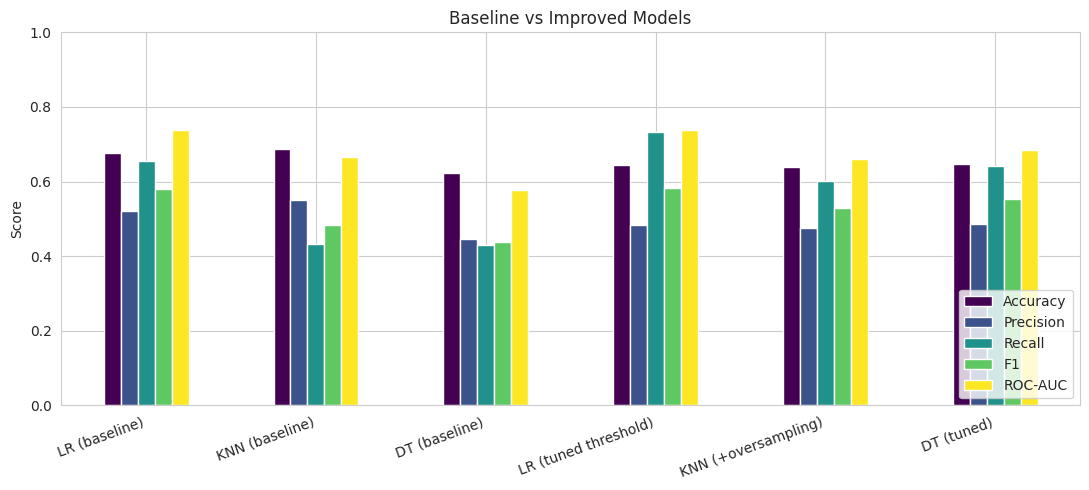

In [132]:
final_df.plot(kind="bar", figsize=(11, 5), colormap="viridis")
plt.title("Baseline vs Improved Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 5.5 Final Model Selection

After tuning, the three models were re-evaluated on the same test set:

| Model | F1 (Returned) | ROC-AUC |
|---|---|---|
| LR (baseline) | 0.5798 | 0.7387 |
| KNN + oversampling | 0.5303 | 0.6593 |
| DT (tuned) | 0.5527 | 0.6857 |
| **LR @ threshold 0.45** | **0.5834** | **0.7387** |

**Logistic Regression with a decision threshold of 0.45 is selected as the final model.** Justification:

- It achieves the highest F1-score for the minority ("Returned") class, which is the class we care about most.
- It retains the highest ROC-AUC (0.7387) — meaning the ranking of predicted probabilities is the strongest across models.
- The 0.45 threshold improves recall on returns from 0.6544 (at default 0.50) to 0.7328, meaning it catches nearly three-quarters of actual returns — critical for an early-warning system.
- Logistic Regression remains fully interpretable via coefficients, which supports explaining *why* an order is flagged.

The tuned threshold will be saved alongside the model and applied in the Streamlit application.

In [133]:
final_model = results["Logistic Regression"]["pipeline"]
final_threshold = best_threshold

joblib.dump({
    "model": final_model,
    "threshold": final_threshold
}, "final_return_risk_model.pkl")

print(f"Saved final model (LR @ threshold {final_threshold}) to final_return_risk_model.pkl")

Saved final model (LR @ threshold 0.45) to final_return_risk_model.pkl


In [134]:
from google.colab import files
files.download("final_return_risk_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>